# 02 – LayoutLM page classification

Fine-tunes `microsoft/layoutlm-base-uncased` to classify scanned document pages into three classes:
`chart_map`, `correspondence` and `other`.

**Input:** the OCR output (words + normalised bounding boxes per page) produced by `01_ocr_extraction.ipynb`.

**Steps:** load data → document-wise train/test split → tokenise → 5-fold cross-validation → pick best fold → evaluate on the held-out test set.


# Setup

In [ ]:
# Install dependencies first (see requirements.txt), e.g.:
#   pip install -r requirements.txt

# ---- Configuration: edit these paths for your setup --------------------------
OCR_DATA_PATH = "data/pages_ocr.json"   # output of 01_ocr_extraction.ipynb (JSON lines)
output_dir = "outputs/models/"          # fine-tuned model weights (one per fold)
log_dir = "outputs/logs/"               # per-fold training metrics


In [ ]:
import json
import os
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm
from datasets import Features, Sequence, ClassLabel, Value, Array2D, Dataset
from sklearn.metrics import classification_report
from sklearn.model_selection import StratifiedKFold, train_test_split
from transformers import LayoutLMTokenizer, LayoutLMForSequenceClassification


# Read data

In [ ]:
merged_data_with_correspondences_OCR = pd.read_json(OCR_DATA_PATH, orient="records", lines=True)
merged_data_with_correspondences_OCR.shape, merged_data_with_correspondences_OCR['label'].value_counts()

In [ ]:
# Merge the two visual classes into one: charts and maps are treated as a single class
merged_data_with_correspondences_OCR['label'] = merged_data_with_correspondences_OCR['label'].replace(['chart', 'map'], 'chart_map')

# Remove pages where OCR found no words (nothing for the model to read)
empty_words_count = (merged_data_with_correspondences_OCR['words'].apply(len) == 0).sum()
print(f"Pages with empty 'words' list (removed): {empty_words_count}")
merged_data_with_correspondences_OCR = merged_data_with_correspondences_OCR[
    merged_data_with_correspondences_OCR['words'].apply(len) > 0
]

merged_data_with_correspondences_OCR.shape, merged_data_with_correspondences_OCR['label'].value_counts()

((1340, 7),
 label
 other             531
 correspondence    498
 chart_map         311
 Name: count, dtype: int64)

# Splitting

Document-wise split: all pages of a document go either to train/validation or to test, so the model is never evaluated on pages from a document it saw in training. The split is stratified by each document's most frequent (dominant) label.

In [ ]:
# Get label distribution for each path
path_label_counts = merged_data_with_correspondences_OCR.groupby(['path', 'label']).size().unstack(fill_value=0)
path_label_counts

In [ ]:

# Add a column for the dominant label in each path (optional but can help with stratification)
path_label_counts['dominant_label'] = path_label_counts.idxmax(axis=1)

path_label_counts

In [ ]:
# Define test size (e.g., 20% of the unique paths)
test_size = 0.2

# Perform stratified splitting based on the dominant label in each path
train_val_paths, test_paths = train_test_split(
    path_label_counts.index,
    test_size=test_size,
    stratify=path_label_counts['dominant_label'],  # Stratify based on the dominant label
    random_state=40
)

In [ ]:
len(train_val_paths), len(test_paths)

(380, 95)

In [ ]:
# Now filter the original dataset based on the split paths
train_val_data = merged_data_with_correspondences_OCR[merged_data_with_correspondences_OCR['path'].isin(train_val_paths)]
test_data = merged_data_with_correspondences_OCR[merged_data_with_correspondences_OCR['path'].isin(test_paths)]

# Check the label distribution in both sets
print("Train/Validation Label Distribution:")
print(train_val_data['label'].value_counts())
print("\nTest Label Distribution:")
print(test_data['label'].value_counts())

In [ ]:
train_val_data.shape, test_data.shape

((1087, 7), (253, 7))

In [ ]:
# Check for overlapping paths and data
common_paths = set(test_paths) & set(train_val_paths)
if common_paths:
    print(f"Warning: {len(common_paths)} common paths found in train and test")
    print(common_paths)

## Define labels

In [ ]:
labels = ['chart_map', 'correspondence', 'other']
idx2label = {v: k for v, k in enumerate(labels)}
label2idx = {k: v for v, k in enumerate(labels)}
label2idx

{'chart_map': 0, 'correspondence': 1, 'other': 2}

# Encoding

In [ ]:
tokenizer = LayoutLMTokenizer.from_pretrained("microsoft/layoutlm-base-uncased")

In [ ]:
def encode_training_example(example, max_seq_length=512, pad_token_box=[0, 0, 0, 0]):
    words = example['words']
    normalized_word_boxes = example['bbox']

    assert len(words) == len(normalized_word_boxes)

    token_boxes = []
    for word, box in zip(words, normalized_word_boxes):
        word_tokens = tokenizer.tokenize(word)
        token_boxes.extend([box] * len(word_tokens))

    # Truncation of token_boxes
    special_tokens_count = 2
    if len(token_boxes) > max_seq_length - special_tokens_count:
        token_boxes = token_boxes[: (max_seq_length - special_tokens_count)]

    # add bounding boxes of cls + sep tokens
    token_boxes = [[0, 0, 0, 0]] + token_boxes + [[1000, 1000, 1000, 1000]]

    encoding = tokenizer(' '.join(words), padding='max_length', truncation=True)
    # Padding of token_boxes up the bounding boxes to the sequence length.
    input_ids = tokenizer(' '.join(words), truncation=True)["input_ids"]
    padding_length = max_seq_length - len(input_ids)
    token_boxes += [pad_token_box] * padding_length
    encoding['bbox'] = token_boxes
    encoding['label'] = label2idx[example['label']]


    assert len(encoding['input_ids']) == max_seq_length
    assert len(encoding['attention_mask']) == max_seq_length
    assert len(encoding['token_type_ids']) == max_seq_length
    assert len(encoding['bbox']) == max_seq_length

    return encoding

# we need to define the features ourselves as the bbox of LayoutLM are an extra feature
training_features = Features({
    'input_ids': Sequence(feature=Value(dtype='int64')),
    'bbox': Array2D(dtype="int64", shape=(512, 4)),
    'attention_mask': Sequence(Value(dtype='int64')),
    'token_type_ids': Sequence(Value(dtype='int64')),
    'label': ClassLabel(names=list(idx2label.keys())),
    'path': Value(dtype='string'),
    'page_num': Value(dtype='int64'),
    'scanned': Value(dtype='bool'),
    'words': Sequence(feature=Value(dtype='string')),
    'source': Value(dtype='string'),
})

# Train

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 3

## Output folders

In [ ]:
os.makedirs(output_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)

## Cross-val preparation

In [ ]:
# Group by 'path' and count the number of instances for each label in each path
path_label_counts_train_val = train_val_data.groupby(['path', 'label']).size().unstack(fill_value=0)

# Add a column for the dominant label in each path (can be used for stratification)
path_label_counts_train_val['dominant_label'] = path_label_counts_train_val.idxmax(axis=1)

# Initialize StratifiedKFold with the number of splits (n_splits)
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
results = []

In [ ]:
# Set a random seed for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
path_label_counts_train_val.dominant_label.value_counts()

,count
dominant_label,
correspondence,366
other,12
chart_map,2


## k-fold loop

In [ ]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(path_label_counts_train_val.index, path_label_counts_train_val['dominant_label'])):
    print(f"Fold {fold + 1}/{n_splits}")

    # Get the train and validation paths
    train_paths = path_label_counts_train_val.index[train_idx]
    valid_paths = path_label_counts_train_val.index[valid_idx]

    # Filter the original train_val_data based on the paths for this fold
    train_data = train_val_data[train_val_data['path'].isin(train_paths)].reset_index(drop=True)
    valid_data = train_val_data[train_val_data['path'].isin(valid_paths)].reset_index(drop=True)

    print("Train Label Distribution:")
    print(train_data['label'].value_counts())
    print("Validation Label Distribution:")
    print(valid_data['label'].value_counts())


    train_dataset = Dataset.from_pandas(train_data)
    valid_dataset = Dataset.from_pandas(valid_data)

    # Encode training and validation examples
    train_encoded = train_dataset.map(
        lambda example: encode_training_example(example), features=training_features
    )
    valid_encoded = valid_dataset.map(
        lambda example: encode_training_example(example), features=training_features
    )


    train_encoded.set_format(type='torch', columns=['input_ids', 'bbox', 'attention_mask', 'token_type_ids', 'label'])
    valid_encoded.set_format(type='torch', columns=['input_ids', 'bbox', 'attention_mask', 'token_type_ids', 'label'])

    # DataLoader
    train_dataloader = torch.utils.data.DataLoader(train_encoded, batch_size=1, shuffle=True)
    valid_dataloader = torch.utils.data.DataLoader(valid_encoded, batch_size=1, shuffle=False)

    # Model and optimizer setup
    model = LayoutLMForSequenceClassification.from_pretrained(
        "microsoft/layoutlm-base-uncased", num_labels=len(label2idx)
    )
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)

    # Tracking metrics
    fold_metrics = {'fold': fold + 1, 'epochs': []}

    # Training loop
    for epoch in range(num_epochs):
        print("Epoch:", epoch + 1)
        model.train()
        training_loss = 0.0
        training_correct = 0

        for batch in train_dataloader:
            labels = batch["label"].to(device)
            outputs = model(
                input_ids=batch["input_ids"].to(device),
                bbox=batch["bbox"].to(device),
                attention_mask=batch["attention_mask"].to(device),
                token_type_ids=batch["token_type_ids"].to(device),
                labels=labels
            )
            loss = outputs.loss
            training_loss += loss.item()
            predictions = outputs.logits.argmax(-1)
            training_correct += (predictions == labels).float().sum()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        training_accuracy = 100 * training_correct / len(train_dataset)
        print(f"Fold {fold + 1}, Epoch {epoch + 1} - Training Loss: {training_loss / len(train_dataloader):.4f}, Training Accuracy: {training_accuracy.item():.2f}%")

        # Validation loop
        model.eval()
        validation_loss = 0.0
        validation_correct = 0

        with torch.no_grad():
            for batch in valid_dataloader:
                labels = batch["label"].to(device)
                outputs = model(
                    input_ids=batch["input_ids"].to(device),
                    bbox=batch["bbox"].to(device),
                    attention_mask=batch["attention_mask"].to(device),
                    token_type_ids=batch["token_type_ids"].to(device),
                    labels=labels
                )
                loss = outputs.loss
                validation_loss += loss.item()
                predictions = outputs.logits.argmax(-1)
                validation_correct += (predictions == labels).float().sum()

        validation_accuracy = 100 * validation_correct / len(valid_dataset)
        print(f"Fold {fold + 1}, Epoch {epoch + 1} - Validation Loss: {validation_loss / len(valid_dataloader):.4f}, Validation Accuracy: {validation_accuracy.item():.2f}%")

        # Log epoch metrics
        fold_metrics['epochs'].append({
            'epoch': epoch + 1,
            'training_loss': training_loss / len(train_dataloader),
            'training_accuracy': training_accuracy.item(),
            'validation_loss': validation_loss / len(valid_dataloader),
            'validation_accuracy': validation_accuracy.item()
        })

    # Save the model for this fold
    model_save_path = os.path.join(output_dir, f"layoutlm_fold{fold + 1}.pt")
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved at {model_save_path}")

    # Save the metrics for this fold
    results.append(fold_metrics)
    log_save_path = os.path.join(log_dir, f"fold_{fold + 1}_metrics.json")
    with open(log_save_path, 'w') as f:
        json.dump(fold_metrics, f)
    print(f"Metrics saved at {log_save_path}")

# Save all fold results to a single file
all_results_path = os.path.join(log_dir, "cross_validation_results.json")
with open(all_results_path, 'w') as f:
    json.dump(results, f)
print(f"All fold metrics saved at {all_results_path}")

# Evaluation

In [ ]:
def analyze_labels(true_labels, predicted_dicts):
    # Convert data to DataFrame
    df = pd.DataFrame([[i, j[i]] for i, j in zip(true_labels, predicted_dicts)], columns=['label', 'prob'])

    # Get unique labels
    unique_labels = df['label'].unique()
    num_labels = len(unique_labels)

    # Set up the plotting grid - 3 columns and calculate the number of rows needed
    cols = 3
    rows = int(np.ceil(num_labels / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), constrained_layout=True)
    axes = axes.flatten()  # Flatten to easily iterate over them

    # Loop through each unique label and create a histogram plot in each subplot
    for idx, label in enumerate(unique_labels):
        # Filter DataFrame for the current label
        label_df = df[df['label'] == label]

        # Plot histogram on the appropriate subplot
        sns.histplot(label_df['prob'], bins=np.arange(0, 1.1, 0.1), kde=False, ax=axes[idx])

        # Calculate mean and median
        mean_val = label_df['prob'].mean()
        median_val = label_df['prob'].median()

        # Plot mean and median lines
        axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='blue', linestyle='-', label=f'Median: {median_val:.2f}')

        # Set title and labels
        axes[idx].set_title(f"Label '{label}'")
        axes[idx].set_xlabel("Probability")
        axes[idx].set_ylabel("Frequency")
        axes[idx].set_xticks(np.arange(0, 1.1, 0.1))
        axes[idx].legend()

    # Hide any extra subplots if the number of labels is not a perfect multiple of the grid size
    for i in range(num_labels, len(axes)):
        axes[i].axis('off')

    # Display all histograms together
    plt.show()

    # Prepare the predicted labels
    reslist = [list(i.items()) for i in predicted_dicts]
    for i in reslist:
        i.sort(key=lambda x: x[1], reverse=True)

    # Extract the predicted label with the highest probability for each sample
    pred_labels = [i[0][0] for i in reslist]

    print(set(pred_labels))

    # Print classification report
    print(classification_report(true_labels, pred_labels))

## Find best fold

In [ ]:
# Path to saved metrics for each fold

# Initialize variables to track the best fold
best_fold = None
best_val_loss = float('inf')  # Start with a large value for loss
best_val_acc = 0  # Start with 0 for accuracy

# Iterate through each saved fold metrics
for fold_num in range(1, n_splits + 1):
    log_file = os.path.join(log_dir, f"fold_{fold_num}_metrics.json")

    # Load metrics from the saved JSON file
    with open(log_file, 'r') as f:
        fold_metrics = json.load(f)

    # Extract the validation loss and accuracy from the last epoch of this fold
    last_epoch_metrics = fold_metrics['epochs'][-1]  # Get metrics for the last epoch
    val_loss = last_epoch_metrics['validation_loss']
    val_acc = last_epoch_metrics['validation_accuracy']

    print(f"Fold {fold_num} - Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_acc:.2f}%")

    # Determine if this is the best fold based on validation acc
    if val_acc > best_val_acc:
      best_val_loss = val_loss
      best_val_acc = val_acc
      best_fold = fold_num

# Print the best fold based on validation acc
print(f"Best Fold: {best_fold}, Validation Loss: {best_val_loss:.4f}, Validation Accuracy: {best_val_acc:.2f}%")

# Path to the best fold model
best_fold_model_path = os.path.join(output_dir, f"layoutlm_fold{best_fold}.pt")
print(f"Best Fold Model Path: {best_fold_model_path}")


## Evaluate best fold on the held-out test set

In [ ]:
# Load the best fold model
best_fold_model = LayoutLMForSequenceClassification.from_pretrained(
    "microsoft/layoutlm-base-uncased", num_labels=len(label2idx)
)
best_fold_model.load_state_dict(torch.load(best_fold_model_path, map_location=device))
best_fold_model.to(device)

# Evaluate the model on test data
test_dataset = Dataset.from_pandas(test_data.reset_index(drop=True))
test_encoded = test_dataset.map(
    lambda example: encode_training_example(example), features=training_features
)
test_encoded.set_format(type='torch', columns=['input_ids', 'bbox', 'attention_mask', 'token_type_ids', 'label'])
test_dataloader = torch.utils.data.DataLoader(test_encoded, batch_size=1, shuffle=False)

# Get predictions and labels
predictions_test = []
labels_test = []

best_fold_model.eval()
with torch.no_grad():
    for batch in tqdm(test_dataloader):
        outputs = best_fold_model(
            input_ids=batch["input_ids"].to(device),
            bbox=batch["bbox"].to(device),
            attention_mask=batch["attention_mask"].to(device),
            token_type_ids=batch["token_type_ids"].to(device)
        )
        preds = torch.softmax(outputs.logits, dim=1).tolist()[0]
        pred_labels = {label: pred for label, pred in zip(label2idx.keys(), preds)}
        predictions_test.append(pred_labels)
        label = idx2label[batch['label'][0].item()]
        labels_test.append(label)

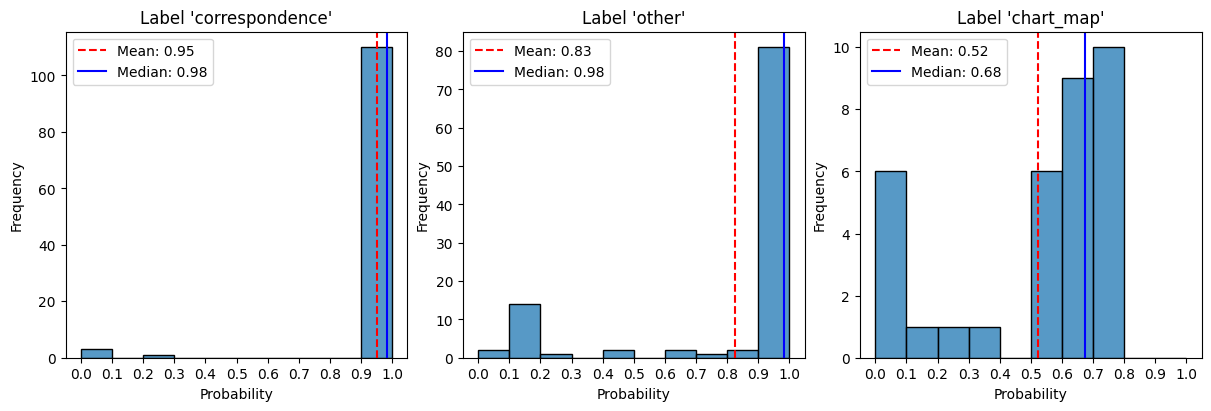

{'other', 'correspondence', 'chart_map'}
                precision    recall  f1-score   support

     chart_map       0.60      0.74      0.66        34
correspondence       0.99      0.96      0.98       114
         other       0.87      0.83      0.85       105

      accuracy                           0.88       253
     macro avg       0.82      0.84      0.83       253
  weighted avg       0.89      0.88      0.88       253



In [ ]:
analyze_labels(labels_test, predictions_test)

## Error analysis

In [ ]:
# Prepare the predicted labels from the probabilities
predicted_labels = []
predicted_probs = []  # Store the probability of the predicted label
actual_probs = []  # Store the probability of the actual label

actual_labels = labels_test  # These are the true labels

for pred_dict, actual_label in zip(predictions_test, actual_labels):
    sorted_preds = sorted(pred_dict.items(), key=lambda x: x[1], reverse=True)
    predicted_labels.append(sorted_preds[0][0])  # Take the label with the highest probability
    predicted_probs.append(sorted_preds[0][1])  # Take the probability of the predicted label
    actual_probs.append(pred_dict[actual_label])  # Get the probability of the actual label


# Convert the true and predicted labels into a DataFrame
results_df = pd.DataFrame({
    'Actual Label': actual_labels,
    'Predicted Label': predicted_labels,
    'Predicted Probability': predicted_probs,
    'Actual Probabilty': actual_probs
})

# Compare actual and predicted labels
results_df['Correct'] = results_df['Actual Label'] == results_df['Predicted Label']

# Add row indices from the original dataset to trace back mismatches
results_df['Index'] = results_df.index

# Filter for rows where predictions were incorrect
incorrect_predictions = results_df[~results_df['Correct']]

# Display incorrect predictions
print(f"Number of incorrect predictions: {len(incorrect_predictions)}")

# Retrieve the original rows from the dataset with incorrect predictions
incorrect_rows = test_data.iloc[incorrect_predictions['Index'].values]

# Combine original rows with prediction information for easier analysis
incorrect_rows = incorrect_rows.copy()
incorrect_rows['Predicted Label'] = incorrect_predictions['Predicted Label'].values
incorrect_rows['Predicted Probability'] = incorrect_predictions['Predicted Probability'].values
incorrect_rows['Actual Probability'] = incorrect_predictions['Actual Probabilty'].values

incorrect_rows[['path', 'page_num', 'label', 'Predicted Label', 'Predicted Probability', 'Actual Probability']]


Number of incorrect predictions: 31


### Correctly classified pages

In [ ]:
# Prepare the predicted labels from the probabilities
predicted_labels = []
predicted_probs = []  # Store the probability of the predicted label
actual_probs = []  # Store the probability of the actual label

actual_labels = labels_test  # These are the true labels

for pred_dict, actual_label in zip(predictions_test, actual_labels):
    sorted_preds = sorted(pred_dict.items(), key=lambda x: x[1], reverse=True)
    predicted_labels.append(sorted_preds[0][0])  # Take the label with the highest probability
    predicted_probs.append(sorted_preds[0][1])  # Take the probability of the predicted label
    actual_probs.append(pred_dict[actual_label])  # Get the probability of the actual label


# Convert the true and predicted labels into a DataFrame
results_df = pd.DataFrame({
    'Actual Label': actual_labels,
    'Predicted Label': predicted_labels,
    'Predicted Probability': predicted_probs,
    'Actual Probabilty': actual_probs
})

# Compare actual and predicted labels
results_df['Correct'] = results_df['Actual Label'] == results_df['Predicted Label']

# Add row indices from the original dataset to trace back mismatches
results_df['Index'] = results_df.index

# Filter for rows where predictions were correct
correct_predictions = results_df[results_df['Correct']]

# Display correct predictions
print(f"Number of correct predictions: {len(correct_predictions)}")

# Retrieve the original rows from the dataset with correct predictions
correct_rows = test_data.iloc[correct_predictions['Index'].values]

# Combine original rows with prediction information for easier analysis
correct_rows = correct_rows.copy()
correct_rows['Predicted Label'] = correct_predictions['Predicted Label'].values
correct_rows['Predicted Probability'] = correct_predictions['Predicted Probability'].values
correct_rows['Actual Probability'] = correct_predictions['Actual Probabilty'].values

correct_rows[['path', 'page_num', 'label', 'Predicted Label', 'Predicted Probability', 'Actual Probability']]
